In [48]:
import numpy as np
import matplotlib.pyplot as plt

# ── Random seed ──────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Parameters ───────────────────────────────────────────────────────────
N_PROFILES   = 300
N_IN_SAMPLE  = 100
N_OUT_SAMPLE = 200
N_MINUTES    = 60

LOAD_MIN  = 220.0   # kW
LOAD_MAX  = 600.0   # kW
DELTA_MAX = 35.0    # kW — max allowed minute-to-minute change
STEP_STD  = 15.0    # kW — std of normal step distribution

In [49]:
def generate_load_profiles(n_profiles, n_minutes, load_min, load_max,
                           delta_max, step_std, rng):
    """
    Generate synthetic load profiles using a clipped random walk.

    Each profile:
      - Starts at a random level in [load_min, load_max]
      - Steps drawn from N(0, step_std^2), clipped to [-delta_max, +delta_max]
      - Level clipped to [load_min, load_max] at every minute

    Returns: ndarray of shape (n_profiles, n_minutes)
    """
    profiles = np.zeros((n_profiles, n_minutes))
    profiles[:, 0] = rng.uniform(load_min, load_max, size=n_profiles)

    for t in range(1, n_minutes):
        steps = rng.normal(0.0, step_std, size=n_profiles)
        steps = np.clip(steps, -delta_max, delta_max)
        profiles[:, t] = np.clip(profiles[:, t-1] + steps, load_min, load_max)

    return profiles


# Generate all 300 profiles
all_profiles = generate_load_profiles(
    N_PROFILES, N_MINUTES, LOAD_MIN, LOAD_MAX, DELTA_MAX, STEP_STD, rng
)

# Split into in-sample and out-of-sample
idx          = rng.permutation(N_PROFILES)
profiles_IS  = all_profiles[idx[:N_IN_SAMPLE]]   # shape (100, 60)
profiles_OOS = all_profiles[idx[N_IN_SAMPLE:]]   # shape (200, 60)

# Sanity checks
print(f"Shape: {all_profiles.shape}")
print(f"Min consumption : {all_profiles.min():.2f} kW  (must be >= {LOAD_MIN})")
print(f"Max consumption : {all_profiles.max():.2f} kW  (must be <= {LOAD_MAX})")
print(f"Max minute step : {np.abs(np.diff(all_profiles, axis=1)).max():.2f} kW  (must be <= {DELTA_MAX})")
print(f"In-sample  : {profiles_IS.shape}")
print(f"Out-of-sample: {profiles_OOS.shape}")

Shape: (300, 60)
Min consumption : 220.00 kW  (must be >= 220.0)
Max consumption : 600.00 kW  (must be <= 600.0)
Max minute step : 35.00 kW  (must be <= 35.0)
In-sample  : (100, 60)
Out-of-sample: (200, 60)


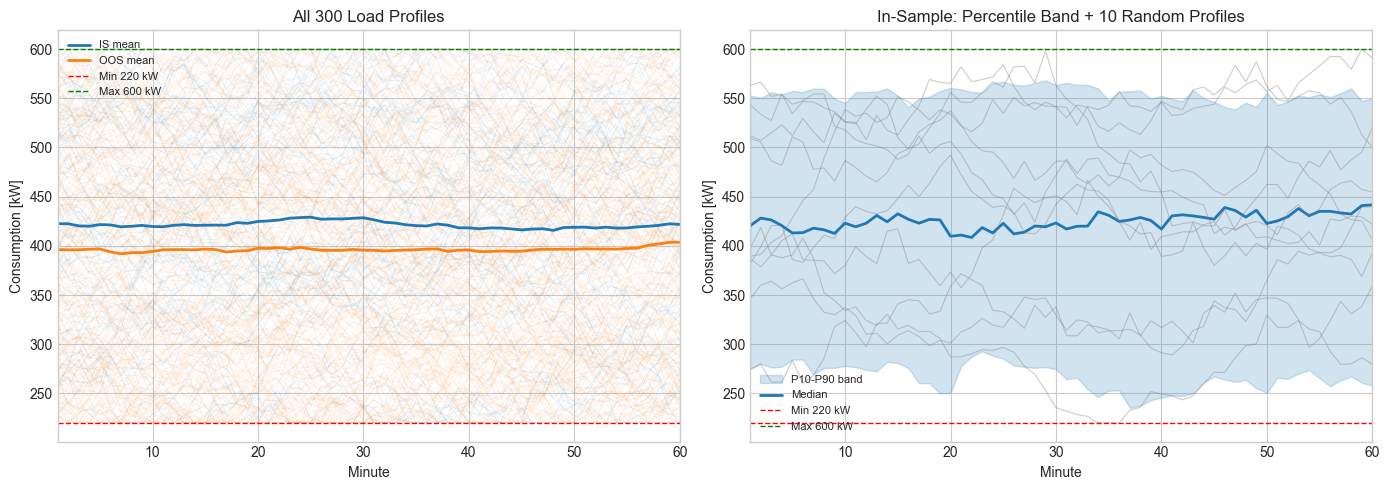

In [50]:
minutes = np.arange(1, N_MINUTES + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: all 300 profiles ────────────────────────────────────────────────
ax = axes[0]
for i in range(N_PROFILES):
    color = '#1f77b4' if i in idx[:N_IN_SAMPLE] else '#ff7f0e'
    ax.plot(minutes, all_profiles[i], color=color, alpha=0.08, linewidth=0.7)
ax.plot(minutes, profiles_IS.mean(axis=0),  color='#1f77b4', linewidth=2, label='IS mean')
ax.plot(minutes, profiles_OOS.mean(axis=0), color='#ff7f0e', linewidth=2, label='OOS mean')
ax.axhline(LOAD_MIN, color='red',   linestyle='--', linewidth=1, label=f'Min {LOAD_MIN:.0f} kW')
ax.axhline(LOAD_MAX, color='green', linestyle='--', linewidth=1, label=f'Max {LOAD_MAX:.0f} kW')
ax.set_xlabel('Minute'); ax.set_ylabel('Consumption [kW]')
ax.set_title('All 300 Load Profiles')
ax.legend(fontsize=8); ax.set_xlim(1, N_MINUTES)

# ── Right: IS percentile band ─────────────────────────────────────────────
ax = axes[1]
p10 = np.percentile(profiles_IS, 10, axis=0)
p50 = np.percentile(profiles_IS, 50, axis=0)
p90 = np.percentile(profiles_IS, 90, axis=0)
ax.fill_between(minutes, p10, p90, alpha=0.2, color='#1f77b4', label='P10-P90 band')
ax.plot(minutes, p50, color='#1f77b4', linewidth=2, label='Median')
for i in rng.choice(N_IN_SAMPLE, size=10, replace=False):
    ax.plot(minutes, profiles_IS[i], color='grey', alpha=0.4, linewidth=0.8)
ax.axhline(LOAD_MIN, color='red',   linestyle='--', linewidth=1, label=f'Min {LOAD_MIN:.0f} kW')
ax.axhline(LOAD_MAX, color='green', linestyle='--', linewidth=1, label=f'Max {LOAD_MAX:.0f} kW')
ax.set_xlabel('Minute'); ax.set_ylabel('Consumption [kW]')
ax.set_title('In-Sample: Percentile Band + 10 Random Profiles')
ax.legend(fontsize=8); ax.set_xlim(1, N_MINUTES)

plt.tight_layout()
plt.savefig('load_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 2.1 — ALSO-X (MILP)

Reformulation of the joint chance-constrained program:

- **Objective:** maximise $c^\uparrow$
- **Big-M constraint:** $c^\uparrow - F^\uparrow_{m,\omega} \leq y_{m,\omega} M \quad \forall m, \omega$
- **Budget constraint:** $\sum_m \sum_\omega y_{m,\omega} \leq q$

With $q = 0.10 \times 60 \times 100 = 600$ and $M = 5000$.

In [51]:
import gurobipy as gp
from gurobipy import GRB

BIG_M   = 10000
EPSILON = 0.10

# Upward flexibility: headroom above LOAD_MIN
# Shape: (100 scenarios, 60 minutes)
F = profiles_IS

n_omega, n_m = F.shape
q = EPSILON * n_omega * n_m

print(f"Scenarios  : {n_omega}")
print(f"Minutes    : {n_m}")
print(f"Budget q   : {q:.0f}  (= {EPSILON} x {n_omega} x {n_m})")
print(f"Big-M      : {BIG_M}")
print(f"Binary vars: {n_omega * n_m}")


Scenarios  : 100
Minutes    : 60
Budget q   : 600  (= 0.1 x 100 x 60)
Big-M      : 10000
Binary vars: 6000


In [52]:
def solve_alsox_milp(F, epsilon, big_m):
    """
    ALSO-X: MILP for the joint chance-constrained FCR-D UP problem.

    Parameters
    ----------
    F       : ndarray (n_omega, n_m)  upward flexibility per scenario/minute
    epsilon : float  violation probability budget (0.10 for P90)
    big_m   : float  big-M constant

    Returns
    -------
    c_star : float  optimal reserve bid [kW]
    """
    n_omega, n_m = F.shape
    q = epsilon * n_omega * n_m

    model = gp.Model("ALSOX_MILP")
    model.setParam("OutputFlag", 1)

    # Decision variables
    c = model.addVar(lb=0.0, name="c_up")
    y = model.addVars(n_omega, n_m, vtype=GRB.BINARY, name="y")

    # Objective: maximise reserve bid
    model.setObjective(c, GRB.MAXIMIZE)

    # Big-M constraints: c - F[omega,m] <= y[omega,m] * M
    for omega in range(n_omega):
        for m in range(n_m):
            model.addConstr(
                c - F[omega, m] <= y[omega, m] * big_m,
                name=f"bigM_{omega}_{m}"
            )

    # Budget constraint: total violations <= q
    model.addConstr(
        gp.quicksum(y[omega, m]
                    for omega in range(n_omega)
                    for m in range(n_m)) <= q,
        name="budget"
    )

    model.optimize()

    if model.Status == GRB.OPTIMAL:
        return model.ObjVal
    else:
        raise RuntimeError(f"Gurobi status: {model.Status}")


c_alsox = solve_alsox_milp(F, EPSILON, BIG_M)
print(f"\nALSO-X optimal FCR-D UP bid: {c_alsox:.4f} kW")


Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-7200U CPU @ 2.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 6001 rows, 6001 columns and 18000 nonzeros
Model fingerprint: 0x6eb4e84a
Variable types: 1 continuous, 6000 integer (6000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+02, 6e+02]
Found heuristic solution: objective 220.0000000
Presolve time: 0.07s
Presolved: 6001 rows, 6001 columns, 18000 nonzeros
Variable types: 1 continuous, 6000 integer (6000 binary)

Root simplex log...

Iteration    Objective       Primal Inf.    Dual Inf.      Time
    5688    1.2436605e+03   9.663370e+02   0.000000e+00      5s
    5879    1.2231006e+03   0.000000e+00   0.000000e+00      6s

Root relaxation

In [53]:
# Sanity check: count violated (minute, scenario) pairs at the optimal bid
violations = (c_alsox > F + 1e-6)   # shape (100, 60), True where bid > flexibility

total_pairs     = n_omega * n_m
n_violated      = violations.sum()
budget_q        = int(q)

print(f"Total (minute, scenario) pairs : {total_pairs}")
print(f"Violated pairs                 : {n_violated}  (budget = {budget_q})")
print(f"Violation fraction             : {n_violated/total_pairs:.4f}  (epsilon = {EPSILON})")
print(f"Budget exactly met             : {n_violated == budget_q}")

# Also show how many scenarios have at least one violated minute
scenarios_with_any_violation = violations.any(axis=1).sum()
print(f"\nScenarios with >= 1 violated minute: {scenarios_with_any_violation} / {n_omega}")


Total (minute, scenario) pairs : 6000
Violated pairs                 : 600  (budget = 600)
Violation fraction             : 0.1000  (epsilon = 0.1)
Budget exactly met             : True

Scenarios with >= 1 violated minute: 27 / 100


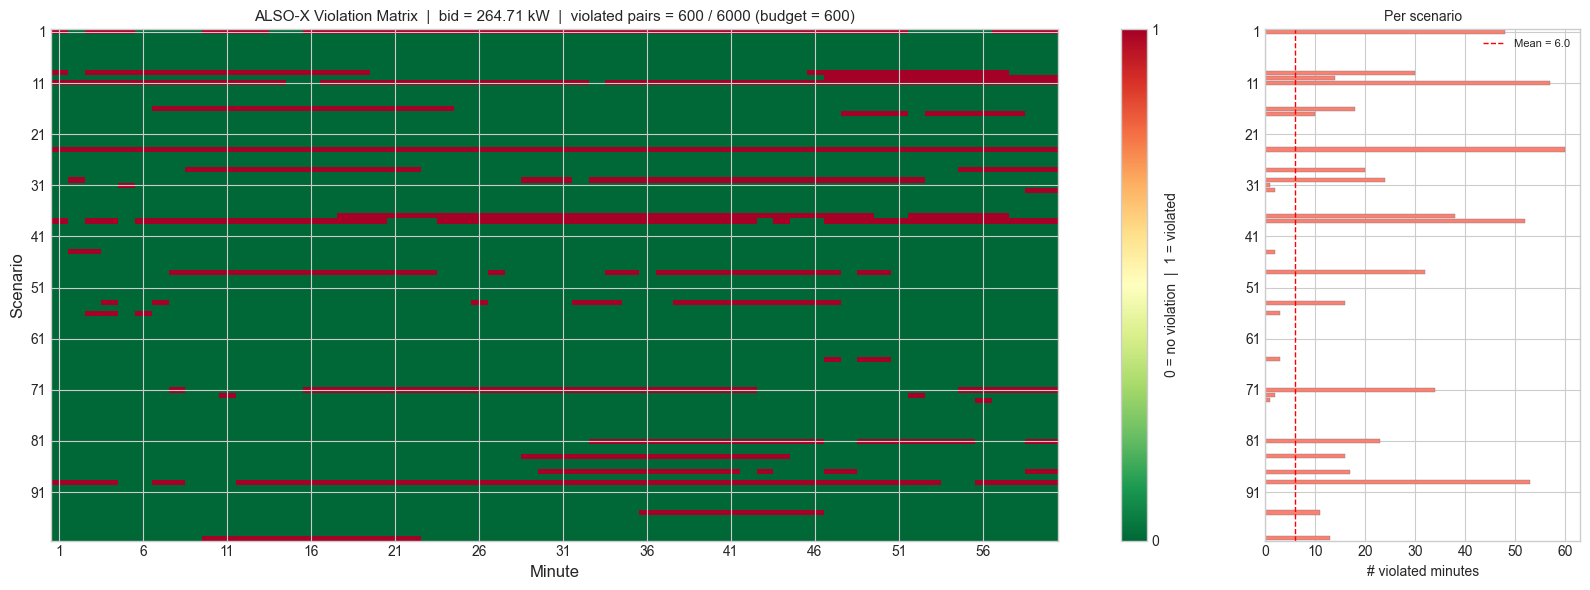

Violated pairs          : 600 / 6000  (budget = 600)
Scenarios with any viol.: 27 / 100
Max violations in 1 scenario: 60 minutes
Avg violations per scenario : 6.0 minutes


In [54]:
import matplotlib.pyplot as plt
import numpy as np

# ── Violation matrix ──────────────────────────────────────────────────────
# violations[omega, m] = True if c_alsox > F[omega, m]
violations = (c_alsox > F + 1e-6)   # shape (100, 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [4, 1]})

# ── Left: heatmap (scenarios x minutes) ──────────────────────────────────
ax = axes[0]
im = ax.imshow(violations.astype(float), aspect='auto',
               cmap='RdYlGn_r', vmin=0, vmax=1,
               origin='upper', interpolation='none')

ax.set_xlabel('Minute', fontsize=12)
ax.set_ylabel('Scenario', fontsize=12)
ax.set_title(f'ALSO-X Violation Matrix  |  bid = {c_alsox:.2f} kW  '
             f'|  violated pairs = {violations.sum()} / {violations.size} '
             f'(budget = {int(q)})',
             fontsize=11)
ax.set_xticks(np.arange(0, 60, 5))
ax.set_xticklabels(np.arange(1, 61, 5))
ax.set_yticks(np.arange(0, 100, 10))
ax.set_yticklabels(np.arange(1, 101, 10))

plt.colorbar(im, ax=ax, ticks=[0, 1],
             label='0 = no violation  |  1 = violated')

# ── Right: violations per scenario (row sums) ─────────────────────────────
ax2 = axes[1]
violations_per_scenario = violations.sum(axis=1)   # shape (100,)
ax2.barh(np.arange(n_omega), violations_per_scenario,
         color='salmon', edgecolor='grey', linewidth=0.3)
ax2.set_xlabel('# violated minutes', fontsize=10)
ax2.set_title('Per scenario', fontsize=10)
ax2.set_yticks(np.arange(0, 100, 10))
ax2.set_yticklabels(np.arange(1, 101, 10))
ax2.set_ylim(-0.5, 99.5)
ax2.invert_yaxis()

# Vertical line at average
avg = violations_per_scenario.mean()
ax2.axvline(avg, color='red', linestyle='--', linewidth=1,
            label=f'Mean = {avg:.1f}')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('alsox_violation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quick stats ───────────────────────────────────────────────────────────
print(f"Violated pairs          : {violations.sum()} / {violations.size}  (budget = {int(q)})")
print(f"Scenarios with any viol.: {violations.any(axis=1).sum()} / {n_omega}")
print(f"Max violations in 1 scenario: {violations_per_scenario.max()} minutes")
print(f"Avg violations per scenario : {avg:.1f} minutes")

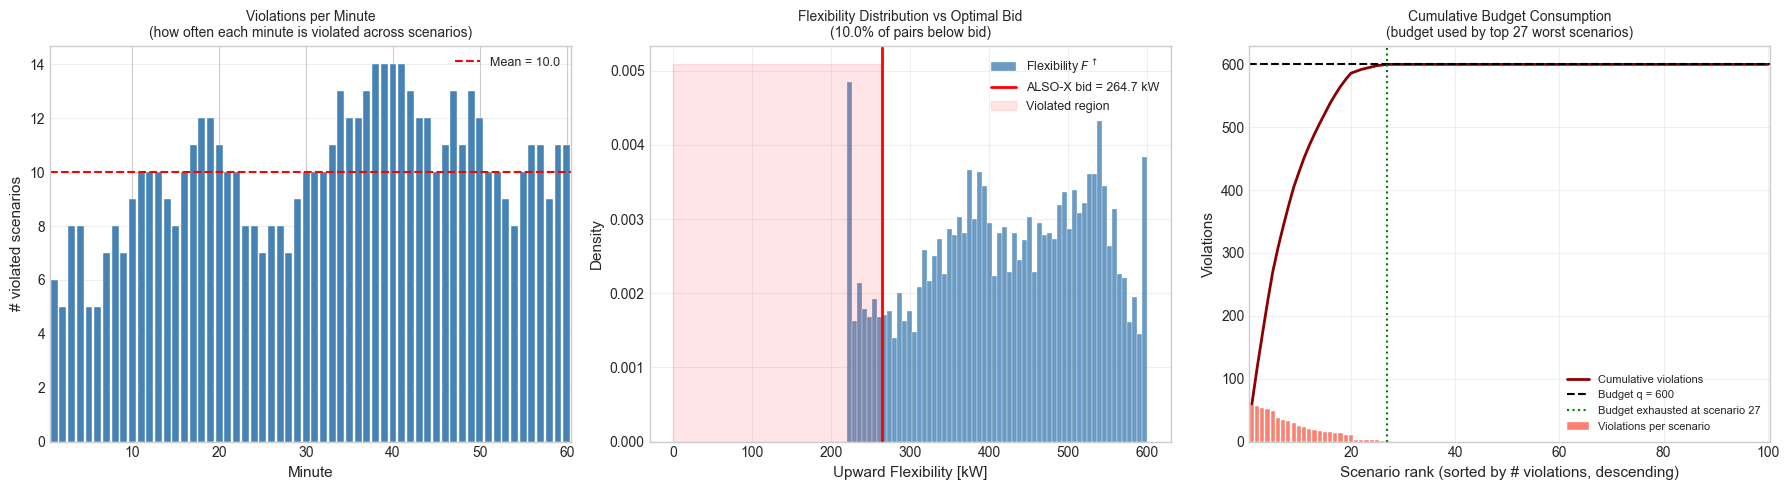

Minute with most violations  : 38  (14 scenarios violated)
Minute with fewest violations: 2  (5 scenarios violated)
% of flexibility pairs below bid : 10.0%
Scenarios responsible for all 600 violations: 27
Scenarios with zero violations : 73


In [55]:
import matplotlib.pyplot as plt
import numpy as np

violations = (c_alsox > F + 1e-6)   # shape (100, 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Violations per minute (column sums) ────────────────────────────────
ax = axes[0]
violations_per_minute = violations.sum(axis=0)   # shape (60,)
ax.bar(np.arange(1, 61), violations_per_minute,
       color='steelblue', edgecolor='white', linewidth=0.3)
ax.axhline(violations_per_minute.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean = {violations_per_minute.mean():.1f}')
ax.set_xlabel('Minute', fontsize=11)
ax.set_ylabel('# violated scenarios', fontsize=11)
ax.set_title('Violations per Minute\n(how often each minute is violated across scenarios)',
             fontsize=10)
ax.set_xlim(0.5, 60.5)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── 2. Flexibility distribution vs bid ───────────────────────────────────
ax = axes[1]
ax.hist(F.flatten(), bins=60, color='steelblue', edgecolor='white',
        linewidth=0.3, density=True, alpha=0.8, label='Flexibility $F^\\uparrow$')
ax.axvline(c_alsox, color='red', linewidth=2,
           label=f'ALSO-X bid = {c_alsox:.1f} kW')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.01],
                 0, c_alsox, alpha=0.1, color='red', label='Violated region')
ax.set_xlabel('Upward Flexibility [kW]', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Flexibility Distribution vs Optimal Bid\n'
             f'({(F.flatten() < c_alsox).mean()*100:.1f}% of pairs below bid)',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 3. Cumulative budget consumption ─────────────────────────────────────
ax = axes[2]
violations_per_scenario = violations.sum(axis=1)   # shape (100,)
sorted_violations = np.sort(violations_per_scenario)[::-1]   # descending
cumulative = np.cumsum(sorted_violations)
scenario_rank = np.arange(1, n_omega + 1)

ax.bar(scenario_rank, sorted_violations, color='salmon',
       edgecolor='white', linewidth=0.3, label='Violations per scenario')
ax.plot(scenario_rank, cumulative, color='darkred', linewidth=2,
        label='Cumulative violations')
ax.axhline(q, color='black', linestyle='--', linewidth=1.5,
           label=f'Budget q = {int(q)}')

# Mark where budget is exhausted
exhausted_at = np.searchsorted(cumulative, q) + 1
ax.axvline(exhausted_at, color='green', linestyle=':', linewidth=1.5,
           label=f'Budget exhausted at scenario {exhausted_at}')

ax.set_xlabel('Scenario rank (sorted by # violations, descending)', fontsize=11)
ax.set_ylabel('Violations', fontsize=11)
ax.set_title('Cumulative Budget Consumption\n'
             f'(budget used by top {exhausted_at} worst scenarios)',
             fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(0.5, n_omega + 0.5)

plt.tight_layout()
plt.savefig('alsox_insights.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stats ─────────────────────────────────────────────────────────────────
print(f"Minute with most violations  : {violations_per_minute.argmax()+1}  "
      f"({violations_per_minute.max()} scenarios violated)")
print(f"Minute with fewest violations: {violations_per_minute.argmin()+1}  "
      f"({violations_per_minute.min()} scenarios violated)")
print(f"% of flexibility pairs below bid : {(F.flatten() < c_alsox).mean()*100:.1f}%")
print(f"Scenarios responsible for all 600 violations: {exhausted_at}")
print(f"Scenarios with zero violations : {(violations_per_scenario == 0).sum()}")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-7200U CPU @ 2.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 6001 rows, 6002 columns and 24001 nonzeros
Model fingerprint: 0x064d2ee6
Coefficient statistics:
  Matrix range     [2e-03, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 6e+02]
Presolve time: 0.04s
Presolved: 6001 rows, 6002 columns, 24001 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
    1617    2.3794682e+02   0.000000e+00   0.000000e+00      0s

Solved in 1617 iterations and 0.44 seconds (0.37 work units)
Optimal objective  2.379468163e+02
CVaR optimal FCR-D UP bid : 237.9468 kW
VaR (beta)                : -26.5312 kW

── Comparison ───────

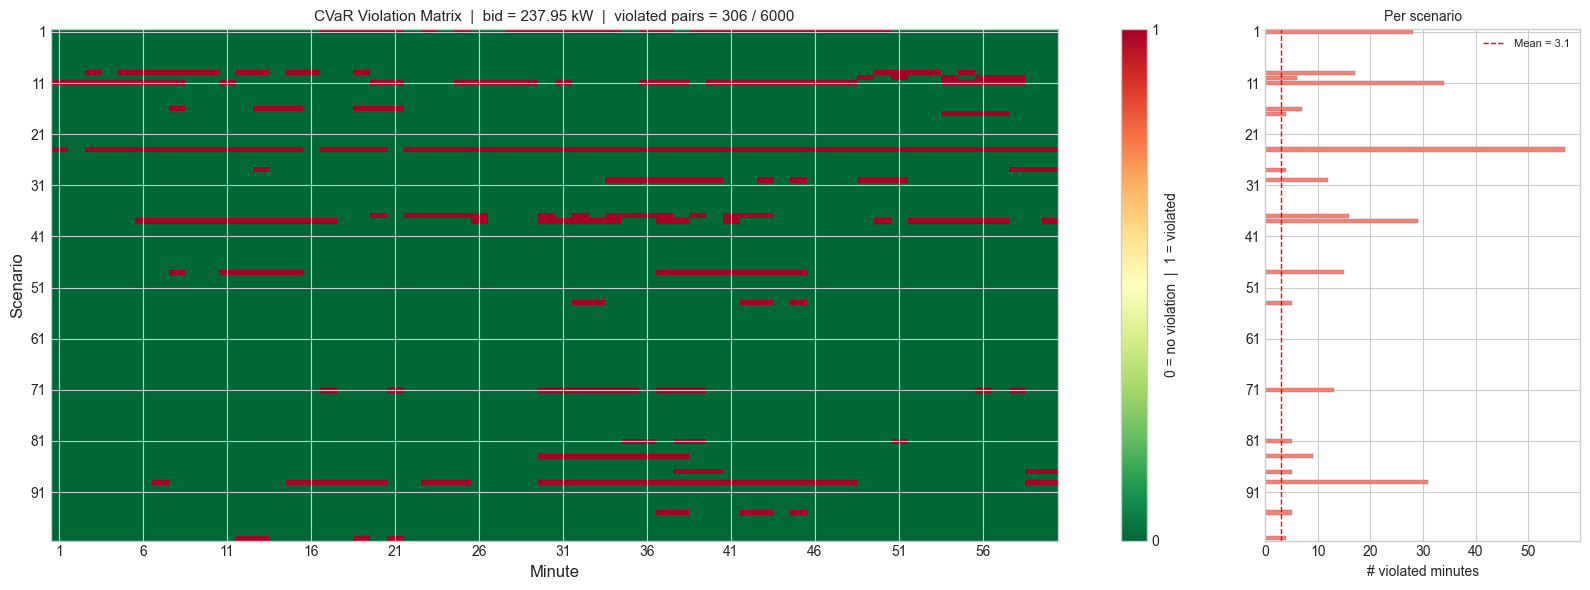

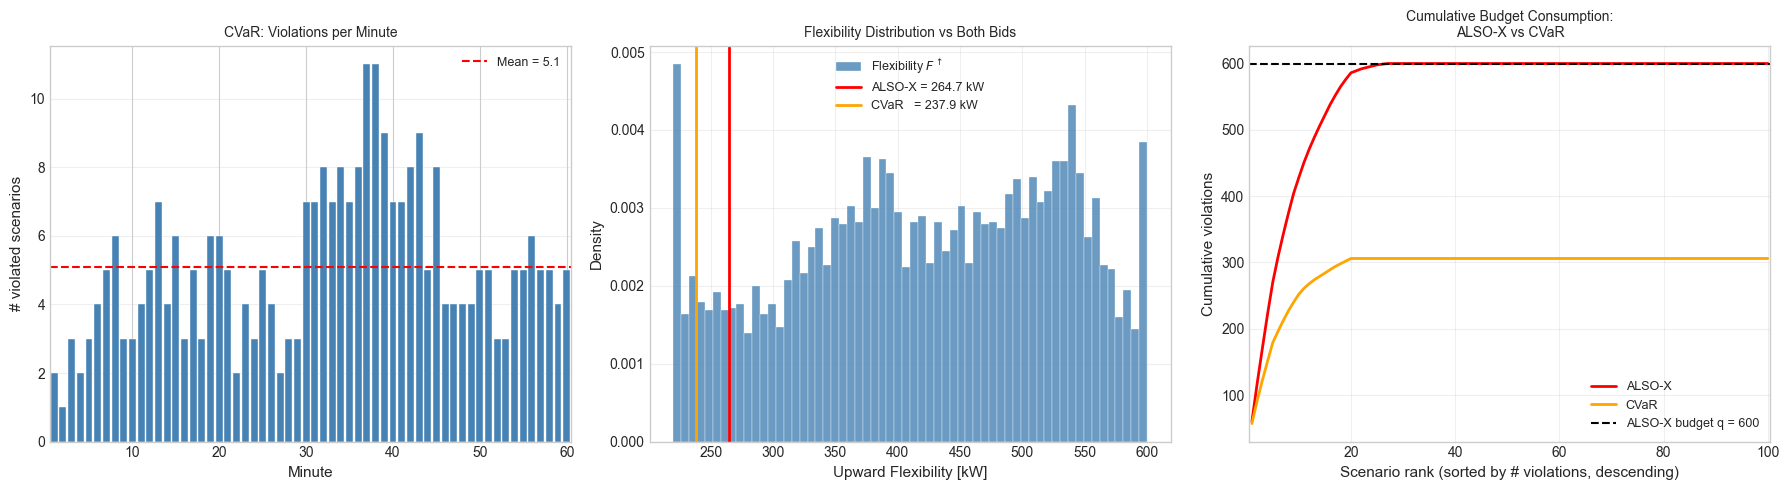

In [56]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches   

# F = profiles_IS - LOAD_MIN   shape (100, 60)
EPSILON = 0.10


def solve_cvar_lp(F, epsilon):
    """
    CVaR approximation (Rockafellar-Uryasev) for FCR-D UP bidding.

      max  c
      s.t.
        beta + (1 / (epsilon * N)) * sum(zeta) <= 0
        zeta[omega,m] >= c - F[omega,m] - beta    for all omega, m
        zeta[omega,m] >= 0                         for all omega, m
        c >= 0,  beta free
    """
    n_omega, n_m = F.shape
    N = n_omega * n_m

    model = gp.Model("CVaR_LP")
    model.setParam("OutputFlag", 1)

    c    = model.addVar(lb=0.0,           name="c_up")
    beta = model.addVar(lb=-GRB.INFINITY, name="beta")   # VaR, free
    zeta = model.addVars(n_omega, n_m, lb=0.0, name="zeta")

    model.setObjective(c, GRB.MAXIMIZE)

    # zeta[omega,m] >= c - F[omega,m] - beta
    for omega in range(n_omega):
        for m in range(n_m):
            model.addConstr(
                zeta[omega, m] >= c - F[omega, m] - beta,
                name=f"zeta_{omega}_{m}"
            )

    # CVaR <= 0
    model.addConstr(
        beta + (1.0 / (epsilon * N)) *
        gp.quicksum(zeta[omega, m]
                    for omega in range(n_omega)
                    for m in range(n_m)) <= 0,
        name="cvar"
    )

    model.optimize()

    if model.Status == GRB.OPTIMAL:
        return model.ObjVal, beta.X
    else:
        raise RuntimeError(f"Gurobi status: {model.Status}")


# ── Solve ─────────────────────────────────────────────────────────────────
c_cvar, beta_cvar = solve_cvar_lp(F, EPSILON)

print(f"CVaR optimal FCR-D UP bid : {c_cvar:.4f} kW")
print(f"VaR (beta)                : {beta_cvar:.4f} kW")
print(f"\n── Comparison ───────────────────────────────")
print(f"  ALSO-X bid : {c_alsox:.4f} kW")
print(f"  CVaR bid   : {c_cvar:.4f} kW")
print(f"  Difference : {c_alsox - c_cvar:.4f} kW  (ALSO-X higher as expected)")


# ═══════════════════════════════════════════════════════════════════════════
# Violation analysis — same plots as ALSO-X for direct comparison
# ═══════════════════════════════════════════════════════════════════════════

violations_cvar = (c_cvar > F + 1e-6)   # shape (100, 60)

print(f"\n── CVaR violation stats ─────────────────────")
print(f"  Violated pairs          : {violations_cvar.sum()} / {violations_cvar.size}")
print(f"  Violation fraction      : {violations_cvar.mean():.4f}  (epsilon = {EPSILON})")
print(f"  Scenarios with any viol.: {violations_cvar.any(axis=1).sum()} / {n_omega}")


# ── Plot 1: Violation heatmap + per-scenario bar ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [4, 1]})

ax = axes[0]
im = ax.imshow(violations_cvar.astype(float), aspect='auto',
               cmap='RdYlGn_r', vmin=0, vmax=1,
               origin='upper', interpolation='none')
ax.set_xlabel('Minute', fontsize=12)
ax.set_ylabel('Scenario', fontsize=12)
ax.set_title(f'CVaR Violation Matrix  |  bid = {c_cvar:.2f} kW  '
             f'|  violated pairs = {violations_cvar.sum()} / {violations_cvar.size}',
             fontsize=11)
ax.set_xticks(np.arange(0, 60, 5))
ax.set_xticklabels(np.arange(1, 61, 5))
ax.set_yticks(np.arange(0, 100, 10))
ax.set_yticklabels(np.arange(1, 101, 10))
plt.colorbar(im, ax=ax, ticks=[0, 1],
             label='0 = no violation  |  1 = violated')

ax2 = axes[1]
vps = violations_cvar.sum(axis=1)
ax2.barh(np.arange(n_omega), vps, color='salmon',
         edgecolor='grey', linewidth=0.3)
ax2.axvline(vps.mean(), color='red', linestyle='--',
            linewidth=1, label=f'Mean = {vps.mean():.1f}')
ax2.set_xlabel('# violated minutes', fontsize=10)
ax2.set_title('Per scenario', fontsize=10)
ax2.set_yticks(np.arange(0, 100, 10))
ax2.set_yticklabels(np.arange(1, 101, 10))
ax2.set_ylim(-0.5, 99.5)
ax2.invert_yaxis()
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('cvar_violation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Plot 2: Three insights side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Violations per minute
ax = axes[0]
vpm = violations_cvar.sum(axis=0)
ax.bar(np.arange(1, 61), vpm, color='steelblue',
       edgecolor='white', linewidth=0.3)
ax.axhline(vpm.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean = {vpm.mean():.1f}')
ax.set_xlabel('Minute', fontsize=11)
ax.set_ylabel('# violated scenarios', fontsize=11)
ax.set_title('CVaR: Violations per Minute', fontsize=10)
ax.set_xlim(0.5, 60.5)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 2) Flexibility distribution vs both bids
ax = axes[1]
ax.hist(F.flatten(), bins=60, color='steelblue', edgecolor='white',
        linewidth=0.3, density=True, alpha=0.8, label='Flexibility $F^\\uparrow$')
ax.axvline(c_alsox, color='red',    linewidth=2, label=f'ALSO-X = {c_alsox:.1f} kW')
ax.axvline(c_cvar,  color='orange', linewidth=2, label=f'CVaR   = {c_cvar:.1f} kW')
ax.set_xlabel('Upward Flexibility [kW]', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Flexibility Distribution vs Both Bids', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 3) Cumulative budget consumption — CVaR vs ALSO-X
ax = axes[2]
# ALSO-X
vps_alsox = (c_alsox > F + 1e-6).sum(axis=1)
sorted_alsox = np.sort(vps_alsox)[::-1]
cum_alsox = np.cumsum(sorted_alsox)
# CVaR
vps_cvar = violations_cvar.sum(axis=1)
sorted_cvar = np.sort(vps_cvar)[::-1]
cum_cvar = np.cumsum(sorted_cvar)

scenario_rank = np.arange(1, n_omega + 1)
ax.plot(scenario_rank, cum_alsox, color='red',    linewidth=2, label='ALSO-X')
ax.plot(scenario_rank, cum_cvar,  color='orange', linewidth=2, label='CVaR')
ax.axhline(int(EPSILON * n_omega * n_m), color='black', linestyle='--',
           linewidth=1.5, label=f'ALSO-X budget q = {int(EPSILON*n_omega*n_m)}')
ax.set_xlabel('Scenario rank (sorted by # violations, descending)', fontsize=11)
ax.set_ylabel('Cumulative violations', fontsize=11)
ax.set_title('Cumulative Budget Consumption:\nALSO-X vs CVaR', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0.5, n_omega + 0.5)

plt.tight_layout()
plt.savefig('cvar_insights.png', dpi=150, bbox_inches='tight')
plt.show()

── Out-of-Sample P90 Verification ───────────────────────────

  ALSO-X bid = 264.71 kW
    Violated pairs     : 1798 / 12000
    Violation fraction : 0.1498  (limit = 0.1)
    P90 satisfied      : False

  CVaR bid = 237.95 kW
    Violated pairs     : 889 / 12000
    Violation fraction : 0.0741  (limit = 0.1)
    P90 satisfied      : True


C:\Users\ir8n8\AppData\Local\Temp\ipykernel_25000\1293118265.py:90: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ir8n8\AppData\Local\Temp\ipykernel_25000\1293118265.py:90: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ir8n8\AppData\Local\Temp\ipykernel_25000\1293118265.py:91: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig('oos_heatmaps.png', dpi=150, bbox_inches='tight')
C:\Users\ir8n8\AppData\Local\Temp\ipykernel_25000\1293118265.py:91: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('oos_heatmaps.png', dpi=150, bbox_inches='tight')
c:\Users\ir8n8\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ir8n8\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 100

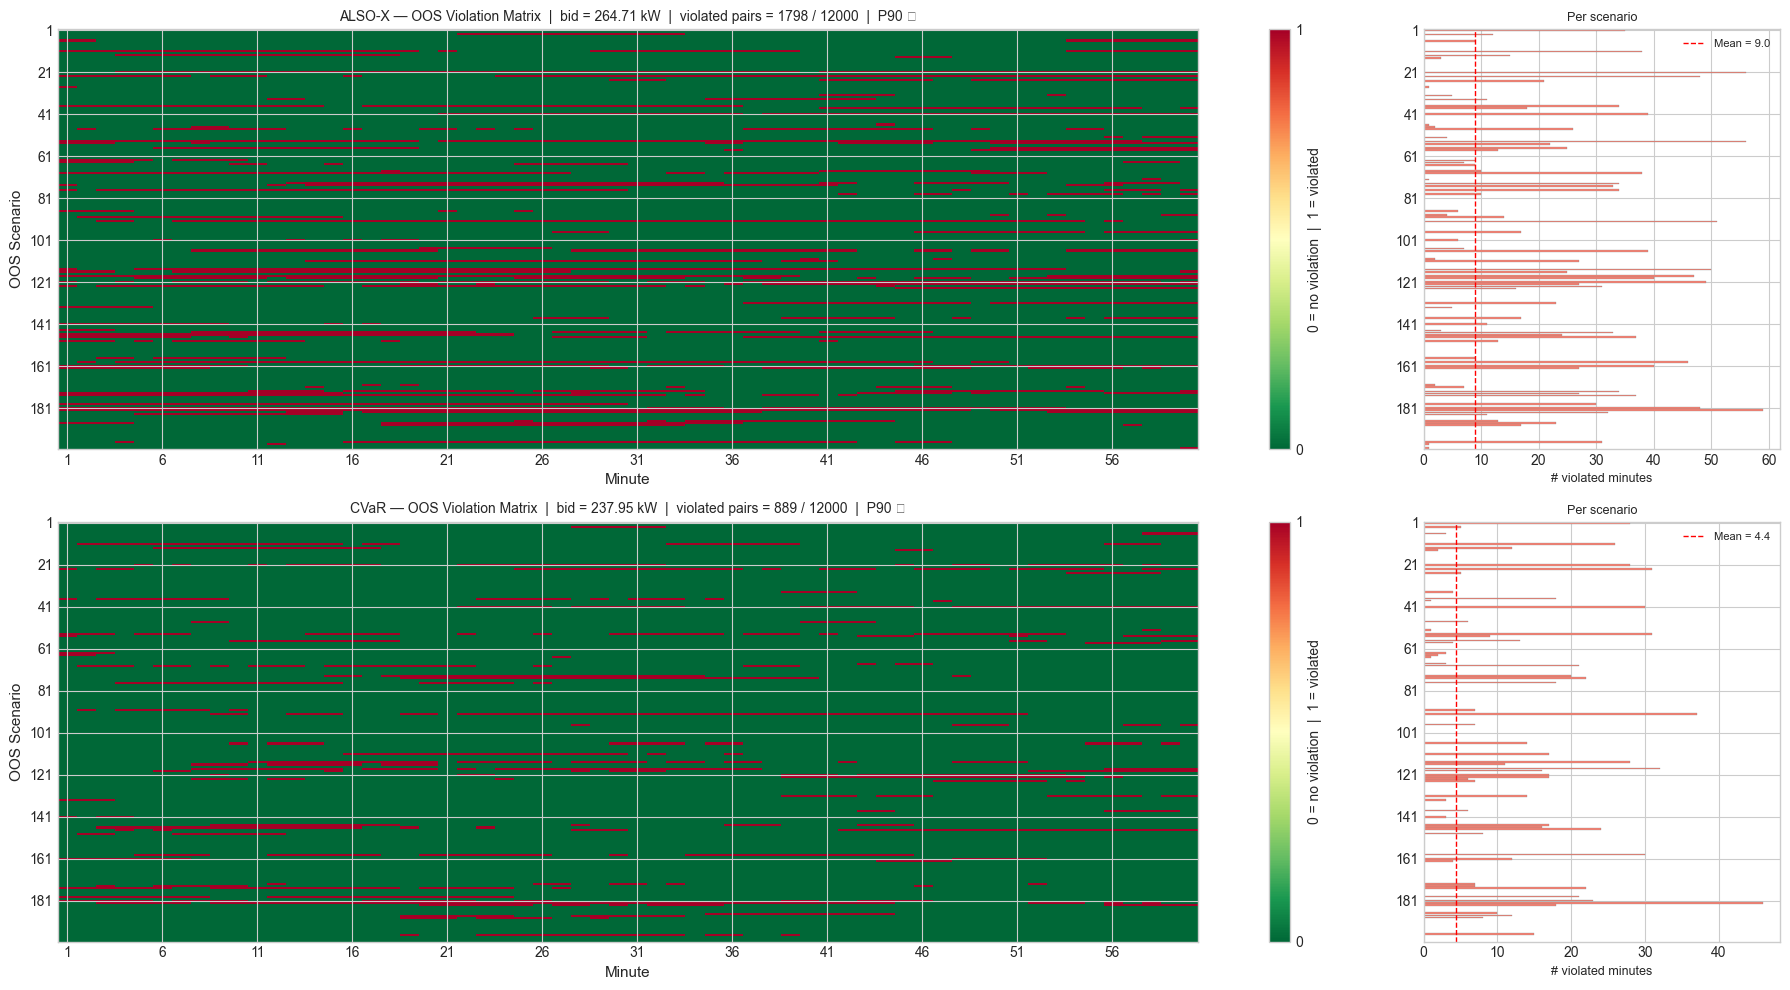

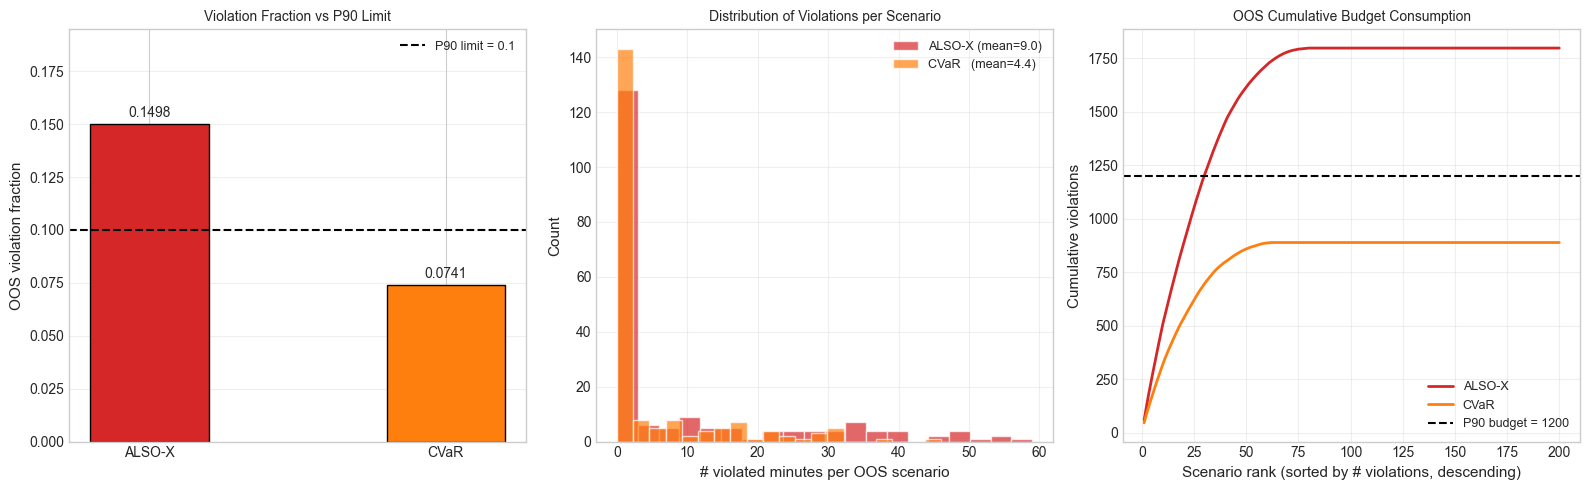

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# F_OOS = out-of-sample flexibility, shape (200, 60)
# c_alsox, c_cvar already defined from Task 2.1
# profiles_OOS already defined from scenario generation

F_OOS     = profiles_OOS  # shape (200, 60)
n_oos     = F_OOS.shape[0]            # 200
minutes   = np.arange(1, N_MINUTES + 1)


def evaluate_p90(c_bid, F_oos, epsilon):
    """
    Evaluate P90 requirement on out-of-sample profiles.

    A (minute, scenario) pair is violated if c_bid > F[omega, m].
    The P90 requirement is satisfied if the violation fraction <= epsilon.

    Returns
    -------
    violated_pairs   : bool array (n_oos, 60)
    pair_viol_rate   : fraction of violated (minute, scenario) pairs
    p90_satisfied    : bool
    vps              : violations per scenario (n_oos,)
    """
    violated_pairs = c_bid > F_oos + 1e-6
    pair_viol_rate = violated_pairs.mean()
    p90_satisfied  = pair_viol_rate <= epsilon
    vps            = violated_pairs.sum(axis=1)
    return violated_pairs, pair_viol_rate, p90_satisfied, vps


# ── Evaluate both methods ─────────────────────────────────────────────────
viol_alsox, rate_alsox, p90_alsox, vps_alsox = evaluate_p90(c_alsox, F_OOS, EPSILON)
viol_cvar,  rate_cvar,  p90_cvar,  vps_cvar  = evaluate_p90(c_cvar,  F_OOS, EPSILON)

print("── Out-of-Sample P90 Verification ───────────────────────────")
print(f"\n  ALSO-X bid = {c_alsox:.2f} kW")
print(f"    Violated pairs     : {viol_alsox.sum()} / {viol_alsox.size}")
print(f"    Violation fraction : {rate_alsox:.4f}  (limit = {EPSILON})")
print(f"    P90 satisfied      : {p90_alsox}")

print(f"\n  CVaR bid = {c_cvar:.2f} kW")
print(f"    Violated pairs     : {viol_cvar.sum()} / {viol_cvar.size}")
print(f"    Violation fraction : {rate_cvar:.4f}  (limit = {EPSILON})")
print(f"    P90 satisfied      : {p90_cvar}")


# ── Plot 1: Violation heatmaps side by side ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10),
                         gridspec_kw={'width_ratios': [4, 1]})

for row, (c_bid, viol, vps, label) in enumerate([
    (c_alsox, viol_alsox, vps_alsox, 'ALSO-X'),
    (c_cvar,  viol_cvar,  vps_cvar,  'CVaR'),
]):
    # Heatmap
    ax = axes[row, 0]
    im = ax.imshow(viol.astype(float), aspect='auto',
                   cmap='RdYlGn_r', vmin=0, vmax=1,
                   origin='upper', interpolation='none')
    ax.set_xlabel('Minute', fontsize=11)
    ax.set_ylabel('OOS Scenario', fontsize=11)
    ax.set_title(f'{label} — OOS Violation Matrix  |  bid = {c_bid:.2f} kW  '
                 f'|  violated pairs = {viol.sum()} / {viol.size}  '
                 f'|  P90 {"✓" if viol.mean() <= EPSILON else "✗"}',
                 fontsize=10)
    ax.set_xticks(np.arange(0, 60, 5))
    ax.set_xticklabels(np.arange(1, 61, 5))
    ax.set_yticks(np.arange(0, 200, 20))
    ax.set_yticklabels(np.arange(1, 201, 20))
    plt.colorbar(im, ax=ax, ticks=[0, 1],
                 label='0 = no violation  |  1 = violated')

    # Per-scenario bar
    ax2 = axes[row, 1]
    ax2.barh(np.arange(n_oos), vps, color='salmon',
             edgecolor='grey', linewidth=0.2)
    ax2.axvline(vps.mean(), color='red', linestyle='--',
                linewidth=1, label=f'Mean = {vps.mean():.1f}')
    ax2.set_xlabel('# violated minutes', fontsize=9)
    ax2.set_title('Per scenario', fontsize=9)
    ax2.set_yticks(np.arange(0, 200, 20))
    ax2.set_yticklabels(np.arange(1, 201, 20))
    ax2.set_ylim(-0.5, 199.5)
    ax2.invert_yaxis()
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('oos_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Plot 2: Summary comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Violation fraction vs epsilon limit
ax = axes[0]
methods = ['ALSO-X', 'CVaR']
rates   = [rate_alsox, rate_cvar]
colors  = ['#d62728', '#ff7f0e']
bars = ax.bar(methods, rates, color=colors, edgecolor='black', width=0.4)
ax.axhline(EPSILON, color='black', linestyle='--',
           linewidth=1.5, label=f'P90 limit = {EPSILON}')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.002,
            f'{rate:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('OOS violation fraction', fontsize=11)
ax.set_title('Violation Fraction vs P90 Limit', fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, max(rates) * 1.3)
ax.grid(axis='y', alpha=0.3)

# 2) Violations per scenario distribution
ax = axes[1]
ax.hist(vps_alsox, bins=20, alpha=0.7, color='#d62728',
        label=f'ALSO-X (mean={vps_alsox.mean():.1f})', edgecolor='white')
ax.hist(vps_cvar,  bins=20, alpha=0.7, color='#ff7f0e',
        label=f'CVaR   (mean={vps_cvar.mean():.1f})', edgecolor='white')
ax.set_xlabel('# violated minutes per OOS scenario', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Violations per Scenario', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 3) Cumulative violations
ax = axes[2]
scenario_rank = np.arange(1, n_oos + 1)
ax.plot(scenario_rank, np.cumsum(np.sort(vps_alsox)[::-1]),
        color='#d62728', linewidth=2, label='ALSO-X')
ax.plot(scenario_rank, np.cumsum(np.sort(vps_cvar)[::-1]),
        color='#ff7f0e', linewidth=2, label='CVaR')
ax.axhline(EPSILON * n_oos * N_MINUTES, color='black', linestyle='--',
           linewidth=1.5, label=f'P90 budget = {int(EPSILON*n_oos*N_MINUTES)}')
ax.set_xlabel('Scenario rank (sorted by # violations, descending)', fontsize=11)
ax.set_ylabel('Cumulative violations', fontsize=11)
ax.set_title('OOS Cumulative Budget Consumption', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('oos_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# ═══════════════════════════════════════════════════════════════════════════
# Task 2.3 — Energinet perspective
# Sensitivity of reserve bid and out-of-sample shortfall to the P-requirement
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure F_OOS exists
F_OOS = profiles_OOS   # upward flexibility, minute-level


def evaluate_oos_shortfall(c_bid, F_eval, epsilon):
    """
    Out-of-sample evaluation for a given reserve bid.

    The interpretation is minute-scenario based:
    a violation occurs when the reserve bid is larger than the available
    upward flexibility in a given profile and minute.
    """
    shortfall = np.maximum(c_bid - F_eval, 0.0)
    violations = shortfall > 1e-6

    return {
        "violation_fraction": violations.mean(),
        "p_requirement_realized": 1.0 - violations.mean(),
        "expected_shortfall_kW": shortfall.mean(),
        "max_shortfall_kW": shortfall.max(),
        "total_shortfall_kW": shortfall.sum(),
        "p_satisfied": violations.mean() <= epsilon + 1e-9,
    }


# P-requirements to test: P80, P85, ..., P100
p_requirements = np.array([0.80, 0.85, 0.90, 0.95, 1.00])

results_alsox = []

for p_req in p_requirements:
    epsilon = 1.0 - p_req

    # Solve in-sample ALSO-X
    c_bid = solve_alsox_milp(F, epsilon, BIG_M)

    # Evaluate out-of-sample
    oos = evaluate_oos_shortfall(c_bid, F_OOS, epsilon)

    results_alsox.append({
        "method": "ALSO-X",
        "P_requirement": p_req,
        "epsilon": epsilon,
        "bid_kW": c_bid,
        "OOS_violation_fraction": oos["violation_fraction"],
        "OOS_realized_reliability": oos["p_requirement_realized"],
        "OOS_expected_shortfall_kW": oos["expected_shortfall_kW"],
        "OOS_max_shortfall_kW": oos["max_shortfall_kW"],
        "OOS_total_shortfall_kW": oos["total_shortfall_kW"],
        "OOS_requirement_satisfied": oos["p_satisfied"],
    })

df_alsox_23 = pd.DataFrame(results_alsox)

print("Task 2.3 — ALSO-X sensitivity analysis")
display(df_alsox_23)

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-7200U CPU @ 2.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 6001 rows, 6001 columns and 18000 nonzeros
Model fingerprint: 0x07ebb28e
Variable types: 1 continuous, 6000 integer (6000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+02, 1e+03]
Found heuristic solution: objective 220.0000000
Presolve time: 0.06s
Presolved: 6001 rows, 6001 columns, 18000 nonzeros
Variable types: 1 continuous, 6000 integer (6000 binary)

Root simplex log...

Iteration    Objective       Primal Inf.    Dual Inf.      Time
    5824    2.2363985e+03   7.039838e+02   0.000000e+00      5s
    5879    2.2227561e+03   0.000000e+00   0.000000e+00      6s

Root relaxation

,method,P_requirement,epsilon,bid_kW,OOS_violation_fraction,OOS_realized_reliability,OOS_expected_shortfall_kW,OOS_max_shortfall_kW,OOS_total_shortfall_kW,OOS_requirement_satisfied
0,ALSO-X,0.80,0.20,320.019571,0.316000,0.684000,16.811170,100.019571,201734.042657,False
1,ALSO-X,0.85,0.15,294.129275,0.239083,0.760917,9.593391,74.129275,115120.687590,False
2,ALSO-X,0.90,0.10,264.713386,0.149833,0.850167,3.897396,44.713386,46768.755200,False
3,ALSO-X,0.95,0.05,237.627563,0.073083,0.926917,0.847631,17.627563,10171.576627,False
4,ALSO-X,1.00,0.00,220.000000,0.000000,1.000000,0.000000,0.000000,0.000000,True


In [59]:
# ═══════════════════════════════════════════════════════════════════════════
# CVaR comparison
# Same epsilon values, but interpreted through the CVaR approximation
# ═══════════════════════════════════════════════════════════════════════════

results_cvar = []

for p_req in p_requirements:
    epsilon = 1.0 - p_req

    # CVaR cannot be evaluated at epsilon = 0 because of division by zero
    if epsilon == 0:
        continue

    # Solve in-sample CVaR approximation
    c_bid, beta_var = solve_cvar_lp(F, epsilon)

    # Evaluate out-of-sample
    oos = evaluate_oos_shortfall(c_bid, F_OOS, epsilon)

    results_cvar.append({
        "method": "CVaR",
        "P_requirement": p_req,
        "epsilon": epsilon,
        "bid_kW": c_bid,
        "VaR_beta_kW": beta_var,
        "OOS_violation_fraction": oos["violation_fraction"],
        "OOS_realized_reliability": oos["p_requirement_realized"],
        "OOS_expected_shortfall_kW": oos["expected_shortfall_kW"],
        "OOS_max_shortfall_kW": oos["max_shortfall_kW"],
        "OOS_total_shortfall_kW": oos["total_shortfall_kW"],
        "OOS_requirement_satisfied": oos["p_satisfied"],
    })

df_cvar_23 = pd.DataFrame(results_cvar)

print("Optional — CVaR sensitivity analysis")
display(df_cvar_23)

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-7200U CPU @ 2.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 6001 rows, 6002 columns and 24001 nonzeros
Model fingerprint: 0x73686989
Coefficient statistics:
  Matrix range     [8e-04, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 6e+02]
Presolve time: 0.03s
Presolved: 6001 rows, 6002 columns, 24001 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
    3065    2.6591017e+02   0.000000e+00   0.000000e+00      1s

Solved in 3065 iterations and 1.10 seconds (1.00 work units)
Optimal objective  2.659101747e+02
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 

,method,P_requirement,epsilon,bid_kW,VaR_beta_kW,OOS_violation_fraction,OOS_realized_reliability,OOS_expected_shortfall_kW,OOS_max_shortfall_kW,OOS_total_shortfall_kW,OOS_requirement_satisfied
0,CVaR,0.80,0.20,265.910175,-54.107581,0.153250,0.846750,4.078889,45.910175,48946.664116,True
1,CVaR,0.85,0.15,251.830851,-42.291258,0.116250,0.883750,2.192264,31.830851,26307.173585,True
2,CVaR,0.90,0.10,237.946816,-26.531210,0.074083,0.925917,0.871156,17.946816,10453.876491,True
3,CVaR,0.95,0.05,225.334200,-12.231251,0.038250,0.961750,0.171421,5.334200,2057.056194,True


In [60]:
def check_in_sample(c_bid, F, epsilon):
    shortfall = np.maximum(c_bid - F, 0.0)
    viol_rate = (shortfall > 1e-6).mean()
    print("IS violation rate:", viol_rate)
    print("Allowed epsilon:", epsilon)
    print("IS satisfied:", viol_rate <= epsilon + 1e-9)

for _, row in df_alsox_23.iterrows():
    print(f"\nP{int(row['P_requirement']*100)}")
    check_in_sample(row["bid_kW"], F, row["epsilon"])


P80
IS violation rate: 0.2
Allowed epsilon: 0.19999999999999996
IS satisfied: True

P85
IS violation rate: 0.15
Allowed epsilon: 0.15000000000000002
IS satisfied: True

P90
IS violation rate: 0.1
Allowed epsilon: 0.09999999999999998
IS satisfied: True

P95
IS violation rate: 0.05
Allowed epsilon: 0.050000000000000044
IS satisfied: True

P100
IS violation rate: 0.0
Allowed epsilon: 0.0
IS satisfied: True


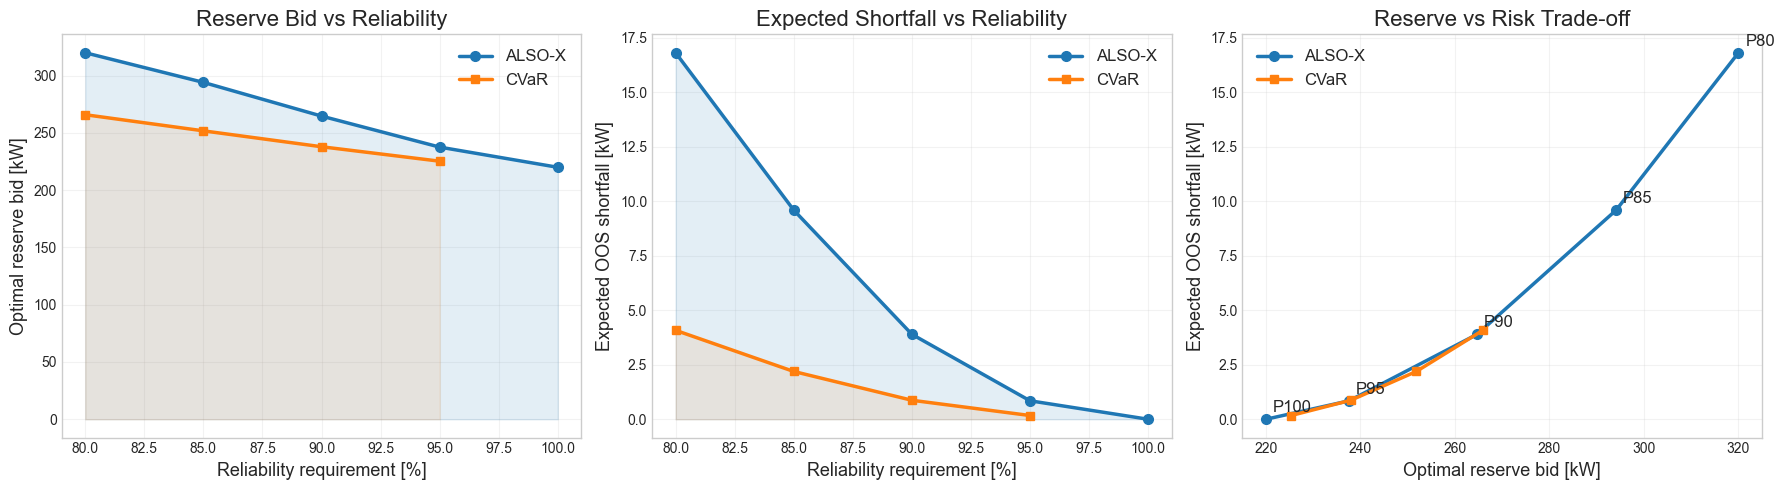

In [61]:
# ═══════════════════════════════════════════════════════════════════════════
# Plots for Task 2.3
# ═══════════════════════════════════════════════════════════════════════════

P_alsox = df_alsox_23["P_requirement"] * 100
B_alsox = df_alsox_23["bid_kW"]
S_alsox = df_alsox_23["OOS_expected_shortfall_kW"]

has_cvar = len(df_cvar_23) > 0

if has_cvar:
    P_cvar = df_cvar_23["P_requirement"] * 100
    B_cvar = df_cvar_23["bid_kW"]
    S_cvar = df_cvar_23["OOS_expected_shortfall_kW"]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ──────────────────────────────────────────────────────────────────────────
# Plot 1 — Reliability vs bid
# ──────────────────────────────────────────────────────────────────────────

ax = axes[0]

ax.plot(
    P_alsox,
    B_alsox,
    color='#1f77b4',
    linewidth=2.5,
    marker='o',
    markersize=7,
    label='ALSO-X'
)

ax.fill_between(
    P_alsox,
    B_alsox,
    alpha=0.12,
    color='#1f77b4'
)

if has_cvar:
    ax.plot(
        P_cvar,
        B_cvar,
        color='#ff7f0e',
        linewidth=2.5,
        marker='s',
        markersize=6,
        label='CVaR'
    )

    ax.fill_between(
        P_cvar,
        B_cvar,
        alpha=0.10,
        color='#ff7f0e'
    )

ax.set_xlabel('Reliability requirement [%]', fontsize=13)
ax.set_ylabel('Optimal reserve bid [kW]', fontsize=13)
ax.set_title('Reserve Bid vs Reliability', fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.25)


# ──────────────────────────────────────────────────────────────────────────
# Plot 2 — Reliability vs expected shortfall
# ──────────────────────────────────────────────────────────────────────────

ax = axes[1]

ax.plot(
    P_alsox,
    S_alsox,
    color='#1f77b4',
    linewidth=2.5,
    marker='o',
    markersize=7,
    label='ALSO-X'
)

ax.fill_between(
    P_alsox,
    S_alsox,
    alpha=0.12,
    color='#1f77b4'
)

if has_cvar:
    ax.plot(
        P_cvar,
        S_cvar,
        color='#ff7f0e',
        linewidth=2.5,
        marker='s',
        markersize=6,
        label='CVaR'
    )

    ax.fill_between(
        P_cvar,
        S_cvar,
        alpha=0.10,
        color='#ff7f0e'
    )

ax.set_xlabel('Reliability requirement [%]', fontsize=13)
ax.set_ylabel('Expected OOS shortfall [kW]', fontsize=13)
ax.set_title('Expected Shortfall vs Reliability', fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.25)


# ──────────────────────────────────────────────────────────────────────────
# Plot 3 — Trade-off curve
# ──────────────────────────────────────────────────────────────────────────

ax = axes[2]

ax.plot(
    B_alsox,
    S_alsox,
    color='#1f77b4',
    linewidth=2.5,
    marker='o',
    markersize=7,
    label='ALSO-X'
)

if has_cvar:
    ax.plot(
        B_cvar,
        S_cvar,
        color='#ff7f0e',
        linewidth=2.5,
        marker='s',
        markersize=6,
        label='CVaR'
    )

# Annotate ALSO-X points
for _, row in df_alsox_23.iterrows():
    ax.annotate(
        f"P{int(row['P_requirement']*100)}",
        (row["bid_kW"], row["OOS_expected_shortfall_kW"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=12
    )

ax.set_xlabel('Optimal reserve bid [kW]', fontsize=13)
ax.set_ylabel('Expected OOS shortfall [kW]', fontsize=13)
ax.set_title('Reserve vs Risk Trade-off', fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.25)


plt.tight_layout()
plt.savefig('task23_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

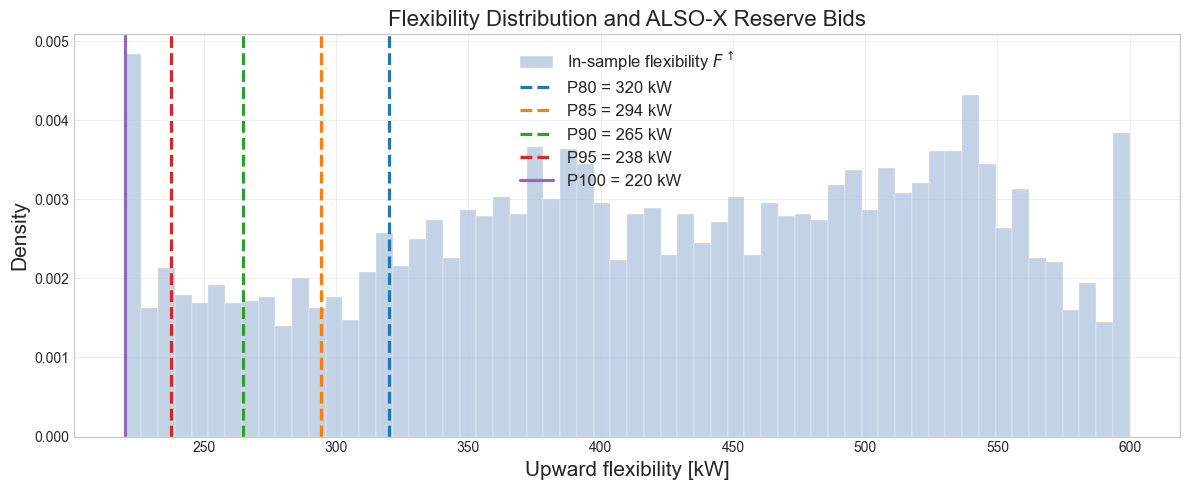

In [62]:
# ═══════════════════════════════════════════════════════════════════════════
# 
# Flexibility distribution and ALSO-X bids
# ═══════════════════════════════════════════════════════════════════════════

selected_P = [0.80, 0.85, 0.90, 0.95, 1.00]
df_sel = df_alsox_23[df_alsox_23["P_requirement"].isin(selected_P)].copy()

p_colors = {
    0.80: "#1f77b4",
    0.85: "#ff7f0e",
    0.90: "#2ca02c",
    0.95: "#d62728",
    1.00: "#9467bd",
}

plt.figure(figsize=(12, 5))

plt.hist(
    F.flatten(),
    bins=60,
    color="lightsteelblue",
    edgecolor="white",
    linewidth=0.3,
    density=True,
    alpha=0.75,
    label=r"In-sample flexibility $F^\uparrow$"
)

for _, row in df_sel.iterrows():
    p = float(row["P_requirement"])
    color = p_colors[p]

    plt.axvline(
        row["bid_kW"],
        color=color,
        linewidth=2.3,
        linestyle="--" if p < 1.0 else "-",
        label=f"P{int(p*100)} = {row['bid_kW']:.0f} kW"
    )

plt.xlabel("Upward flexibility [kW]", fontsize=15)
plt.ylabel("Density", fontsize=15)
plt.title("Flexibility Distribution and ALSO-X Reserve Bids", fontsize=16)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig(
    "task23_flexibility_distribution_bids.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

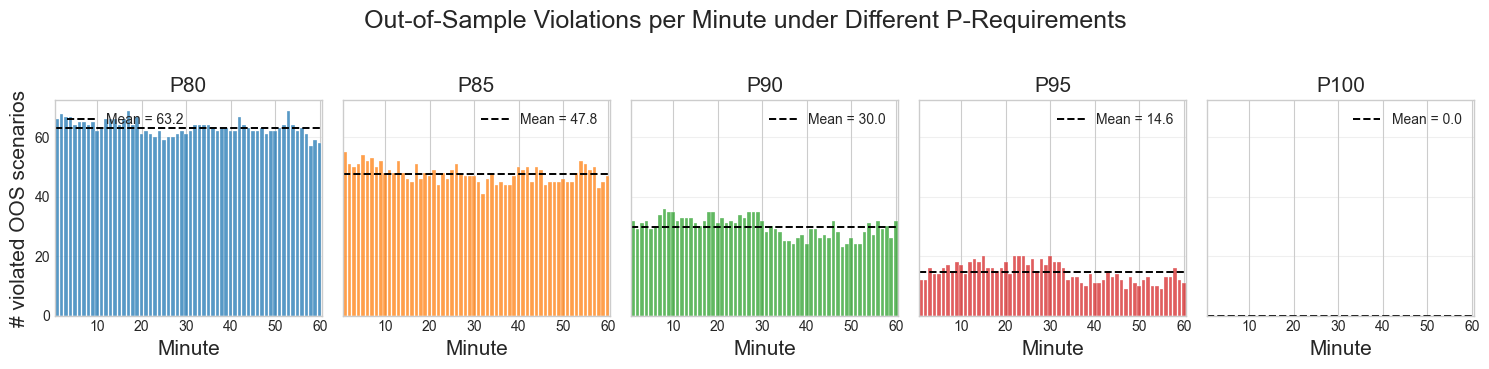

In [63]:
# ═══════════════════════════════════════════════════════════════════════════
# OOS violations per minute for different P-requirements
# ═══════════════════════════════════════════════════════════════════════════

minutes = np.arange(1, N_MINUTES + 1)

fig, axes = plt.subplots(
    1,
    len(df_sel),
    figsize=(15, 3.5),
    sharey=True
)

if len(df_sel) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, df_sel.iterrows()):

    p = float(row["P_requirement"])
    color = p_colors[p]

    c_bid = row["bid_kW"]

    violations = c_bid > F_OOS + 1e-6
    vpm = violations.sum(axis=0)

    ax.bar(
        minutes,
        vpm,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.3
    )

    ax.axhline(
        vpm.mean(),
        color="black",
        linestyle="--",
        linewidth=1.4,
        label=f"Mean = {vpm.mean():.1f}"
    )

    ax.set_title(f"P{int(p*100)}", fontsize=15)
    ax.set_xlabel("Minute", fontsize=15)
    ax.set_xlim(0.5, 60.5)

    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=10)

axes[0].set_ylabel("# violated OOS scenarios", fontsize=15)

fig.suptitle(
    "Out-of-Sample Violations per Minute under Different P-Requirements",
    fontsize=18,
    y=1.04
)

plt.tight_layout()

plt.savefig(
    "task23_oos_violations_per_minute.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [64]:
# ═══════════════════════════════════════════════════════════════════════════
# Compact text summary
# ═══════════════════════════════════════════════════════════════════════════

print("Summary — ALSO-X")
for _, row in df_alsox_23.iterrows():
    print(
        f"P{int(row['P_requirement']*100)}: "
        f"bid = {row['bid_kW']:.2f} kW, "
        f"OOS expected shortfall = {row['OOS_expected_shortfall_kW']:.4f} kW, "
        f"OOS violation rate = {row['OOS_violation_fraction']:.4f}, "
        f"satisfied = {row['OOS_requirement_satisfied']}"
    )

if len(df_cvar_23) > 0:
    print("\nSummary — CVaR")
    for _, row in df_cvar_23.iterrows():
        print(
            f"P{int(row['P_requirement']*100)}: "
            f"bid = {row['bid_kW']:.2f} kW, "
            f"OOS expected shortfall = {row['OOS_expected_shortfall_kW']:.4f} kW, "
            f"OOS violation rate = {row['OOS_violation_fraction']:.4f}, "
            f"satisfied = {row['OOS_requirement_satisfied']}"
        )

Summary — ALSO-X
P80: bid = 320.02 kW, OOS expected shortfall = 16.8112 kW, OOS violation rate = 0.3160, satisfied = False
P85: bid = 294.13 kW, OOS expected shortfall = 9.5934 kW, OOS violation rate = 0.2391, satisfied = False
P90: bid = 264.71 kW, OOS expected shortfall = 3.8974 kW, OOS violation rate = 0.1498, satisfied = False
P95: bid = 237.63 kW, OOS expected shortfall = 0.8476 kW, OOS violation rate = 0.0731, satisfied = False
P100: bid = 220.00 kW, OOS expected shortfall = 0.0000 kW, OOS violation rate = 0.0000, satisfied = True

Summary — CVaR
P80: bid = 265.91 kW, OOS expected shortfall = 4.0789 kW, OOS violation rate = 0.1532, satisfied = True
P85: bid = 251.83 kW, OOS expected shortfall = 2.1923 kW, OOS violation rate = 0.1163, satisfied = True
P90: bid = 237.95 kW, OOS expected shortfall = 0.8712 kW, OOS violation rate = 0.0741, satisfied = True
P95: bid = 225.33 kW, OOS expected shortfall = 0.1714 kW, OOS violation rate = 0.0382, satisfied = True
